In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timedelta
import polars as pl

from thrs.control.modules.lt2 import Lt2Control, Lt2Parameters
from thrs.input_output.alarms import BaseAlarms
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    Converter,
)
from thrs.input_output.modules.lt2 import (
    Lt2ControlValues,
    Lt2SensorValues,
    Lt2SimulationInputs,
    Lt2SimulationOutputs,
)
from thrs.orchestration.simulator import Simulator, SimulatorModel

from thrs.simulation.models.fmu_paths import lt2_path

start_time = datetime.fromtimestamp(0)
minutes = 60
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)

SEAWATER_TEMPERATURE = 20.0

simulation_inputs = Lt2SimulationInputs(
    lt2_brightloop_fwd1=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_brightloop_fwd2=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_ugrid1=Converter(heat_flow=Stamped.stamp(2000), active=Stamped.stamp(True)),
    lt2_ugrid2=Converter(heat_flow=Stamped.stamp(2000), active=Stamped.stamp(True)),
    lt2_brightloop_aft1=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_brightloop_aft2=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_brightloop_aft3=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_brightloop_aft4=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_seawater_supply=Boundary(
        temperature=Stamped.stamp(SEAWATER_TEMPERATURE), flow=Stamped.stamp(64)
    ),
    lt2_boilers_supply=Boundary(temperature=Stamped.stamp(35), flow=Stamped.stamp(20)),
)

parameters = Lt2Parameters(
    maximum_supply_temperature=63,
    recovery_temperature=65,
    brightloop_return_temperature=65,
    ugrid_return_temperature=65,
)


lt2_model = SimulatorModel(
    fmu_path=lt2_path,
    sensor_values_cls=Lt2SensorValues,
    control_values_cls=Lt2ControlValues,
    simulation_outputs_cls=Lt2SimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=Lt2Control,
    control_parameters=parameters,
    alarms=BaseAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)
with lt2_model.executor() as executor:
    simulation = Simulator.from_model(lt2_model, executor)
    result = await simulation.run(int(duration.total_seconds()))

[WARNING] State logging: Please enable result storing to get state names
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 34.3208, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 50.2116, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 60.7408, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 145.635, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 212.648, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 295.638, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 320.817, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 324.666, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_T

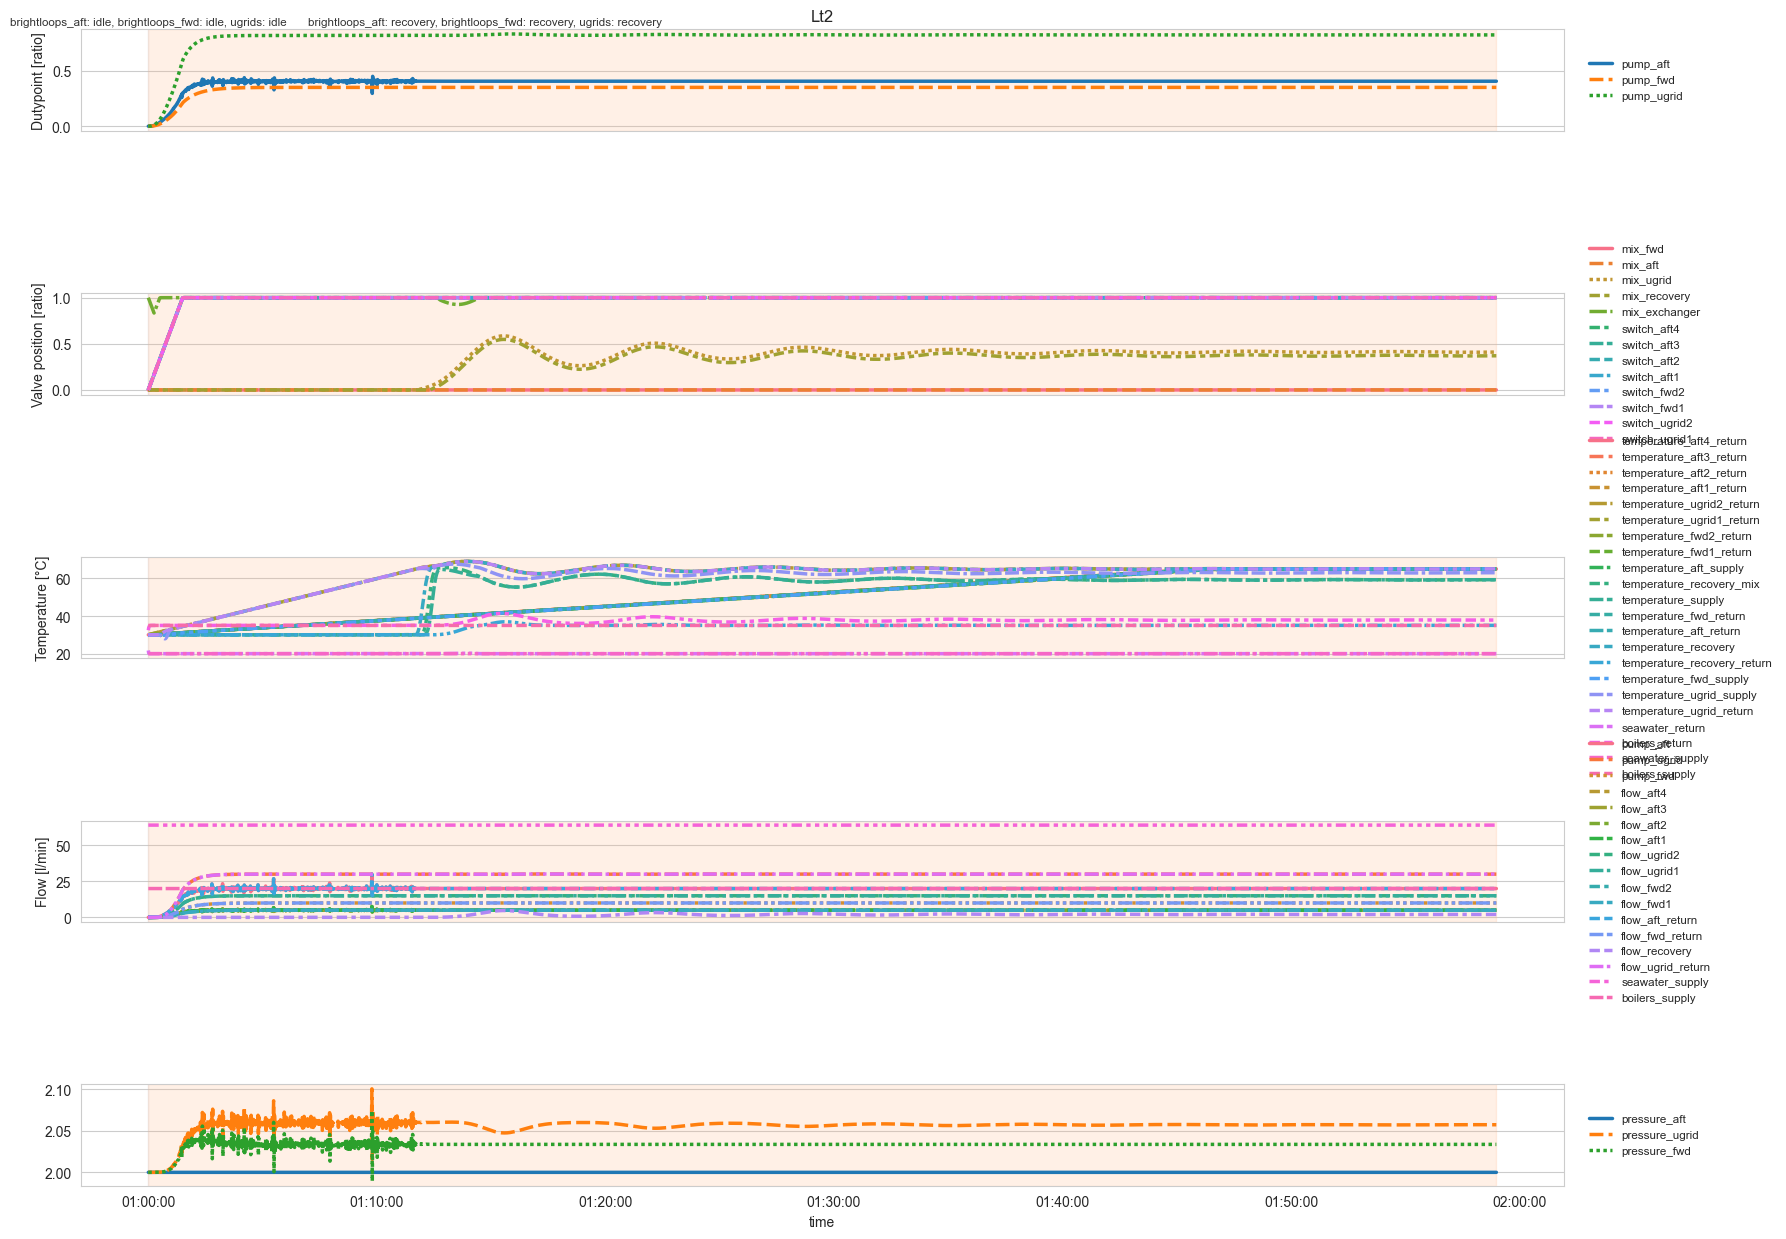

In [3]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/lt2.png");

(<Figure size 1800x1250 with 5 Axes>,
 array([[<Axes: title={'center': 'Lt2'}, xlabel='time', ylabel='Dutypoint [ratio]'>],
        [<Axes: xlabel='time', ylabel='Valve position [ratio]'>],
        [<Axes: xlabel='time', ylabel='Temperature [°C]'>],
        [<Axes: xlabel='time', ylabel='Flow [l/min]'>],
        [<Axes: xlabel='time'>]], dtype=object))

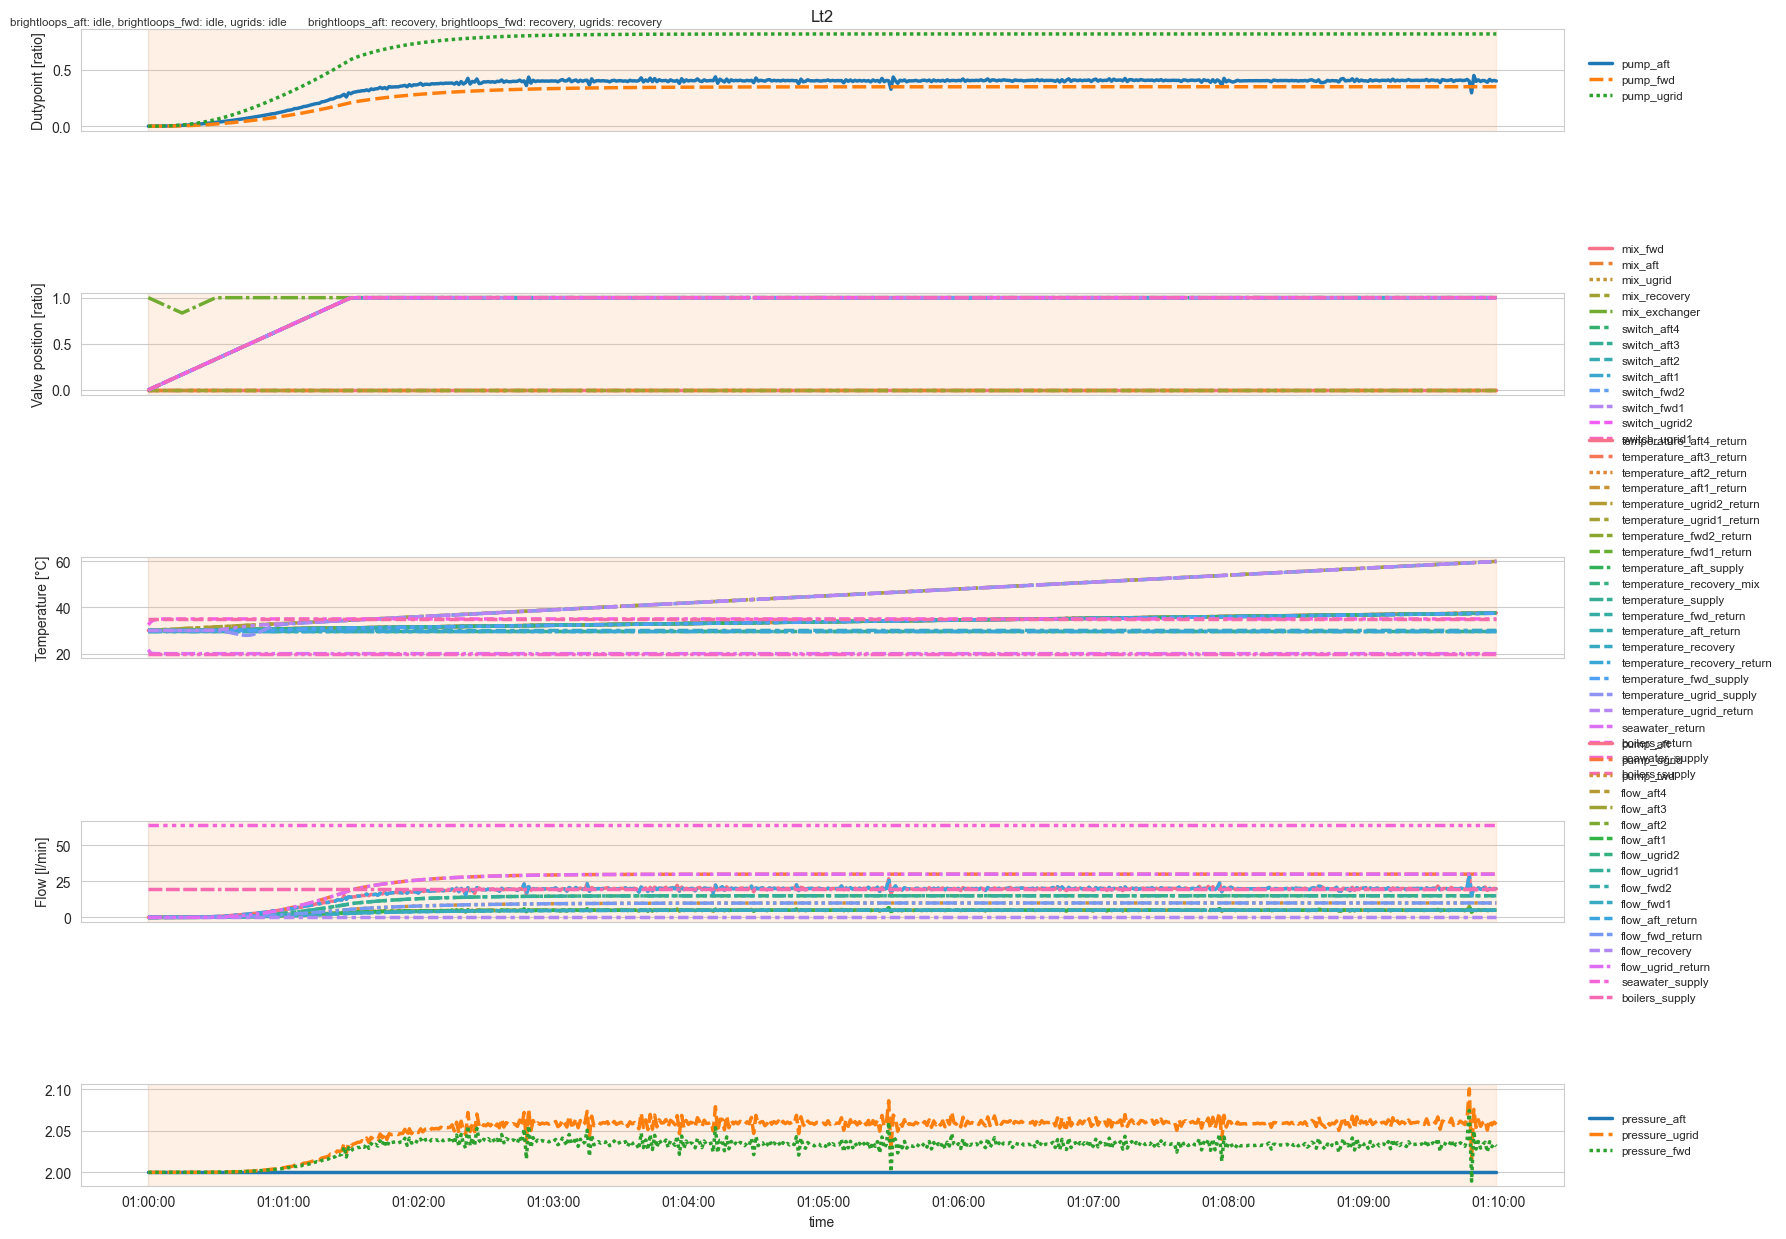

In [4]:
from analysis.analysis_utils import plot_result

plot_result(result.head(600), path = 'test')

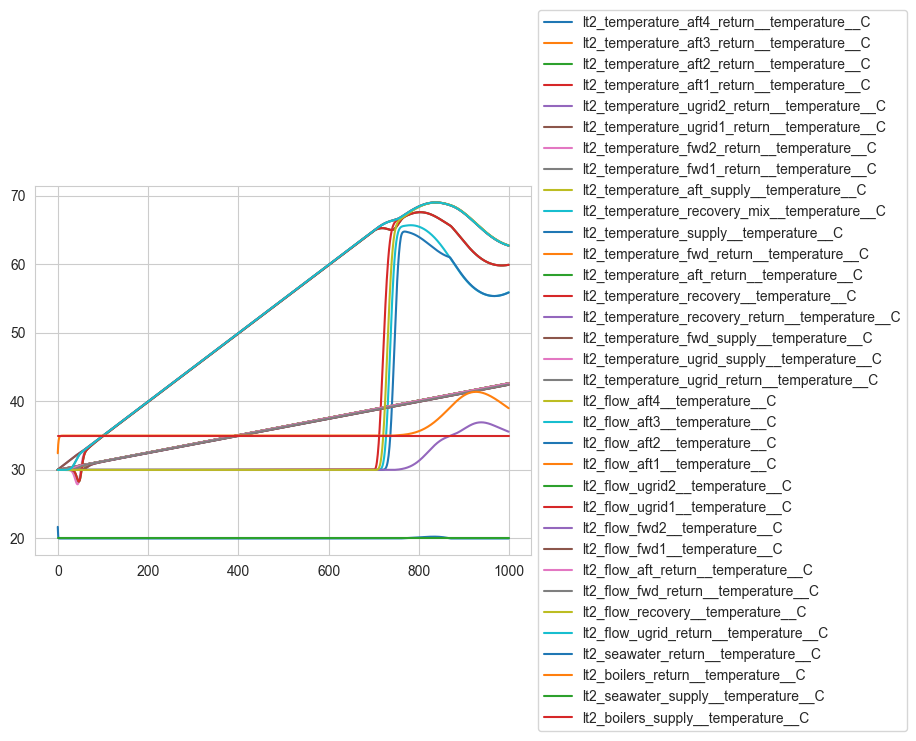

In [5]:
ax = result[[x for x in result.columns if "temperature" in x]].to_pandas().head(1000).plot()
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

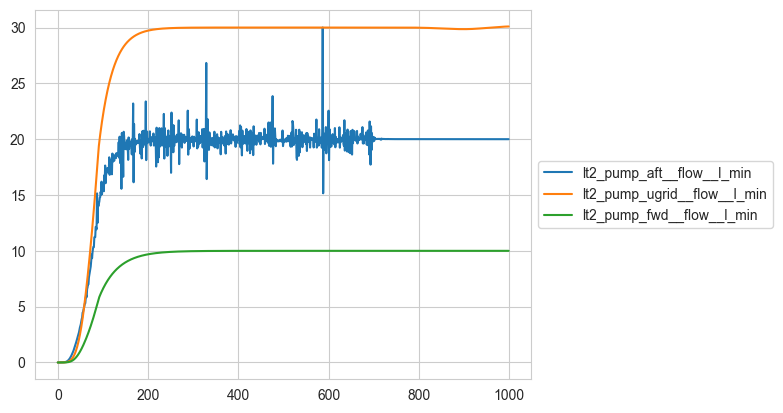

In [30]:
ax = result[[x for x in result.columns if ("flow__l_min" in x) and ("pump" in x)]].to_pandas().head(1000).plot()
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

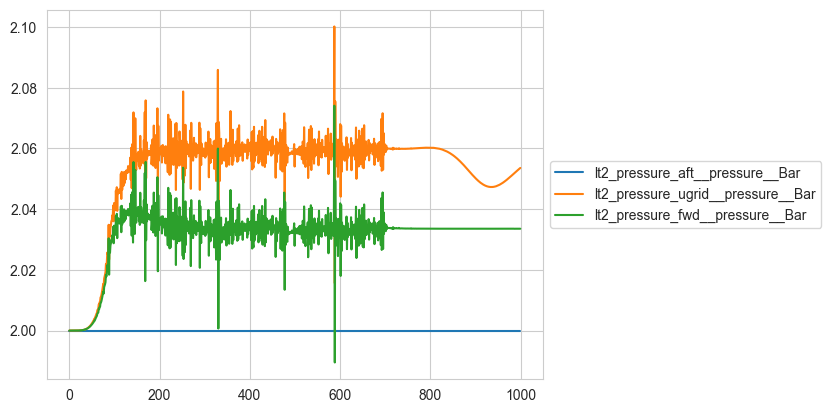

In [31]:
ax = result[[x for x in result.columns if ("pressure" in x)]].to_pandas().head(1000).plot()
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

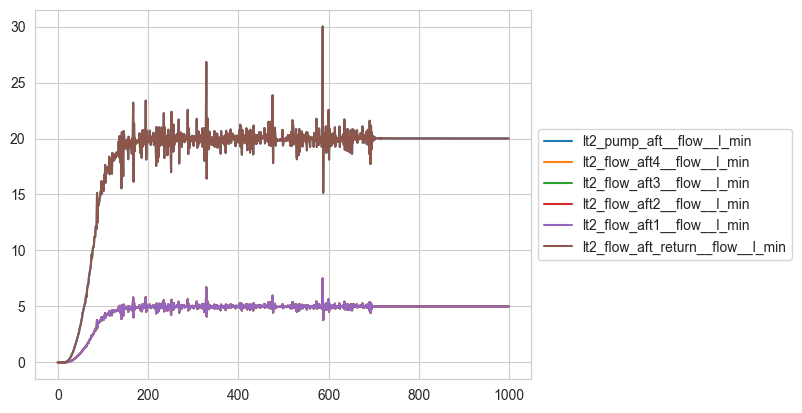

In [ ]:
ax = result[[x for x in result.columns if ("flow__l_min" in x) and 'aft' in x]].to_pandas().head(1000).plot()
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

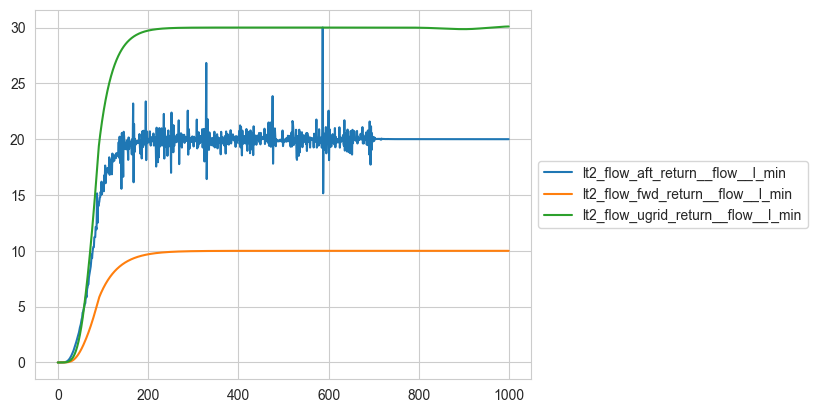

In [27]:
ax = result[[x for x in result.columns if ("return__flow__l_min" in x)]].to_pandas().head(1000).plot()
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

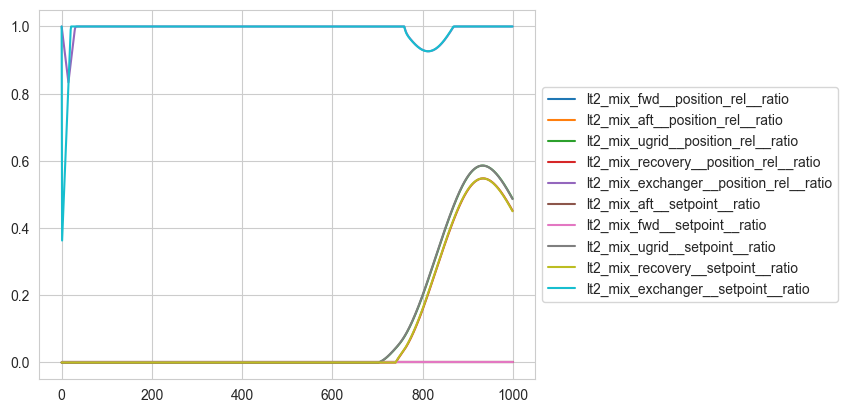

In [29]:
ax = result[[x for x in result.columns if ("lt2_mix" in x)]].to_pandas().head(1000).plot()
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

In [24]:
result[[x for x in result.columns if 'flow__l_min' in x]][400]

lt2_pump_aft__flow__l_min,lt2_pump_ugrid__flow__l_min,lt2_pump_fwd__flow__l_min,lt2_flow_aft4__flow__l_min,lt2_flow_aft3__flow__l_min,lt2_flow_aft2__flow__l_min,lt2_flow_aft1__flow__l_min,lt2_flow_ugrid2__flow__l_min,lt2_flow_ugrid1__flow__l_min,lt2_flow_fwd2__flow__l_min,lt2_flow_fwd1__flow__l_min,lt2_flow_aft_return__flow__l_min,lt2_flow_fwd_return__flow__l_min,lt2_flow_recovery__flow__l_min,lt2_flow_ugrid_return__flow__l_min,lt2_seawater_supply__flow__l_min,lt2_boilers_supply__flow__l_min
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
19.970339,29.999691,9.997417,4.992585,4.992585,4.992585,4.992585,14.999846,14.999846,4.998701,4.998716,19.970339,9.997417,9.5830e-12,29.999691,64.0,20.0


In [25]:
result[[x for x in result.columns if 'position_rel' in x]][400]

lt2_mix_fwd__position_rel__ratio,lt2_mix_aft__position_rel__ratio,lt2_mix_ugrid__position_rel__ratio,lt2_mix_recovery__position_rel__ratio,lt2_mix_exchanger__position_rel__ratio,lt2_switch_aft4__position_rel__ratio,lt2_switch_aft3__position_rel__ratio,lt2_switch_aft2__position_rel__ratio,lt2_switch_aft1__position_rel__ratio,lt2_switch_fwd2__position_rel__ratio,lt2_switch_fwd1__position_rel__ratio,lt2_switch_ugrid2__position_rel__ratio,lt2_switch_ugrid1__position_rel__ratio
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.00001,0.00001,0.00001,0.00001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


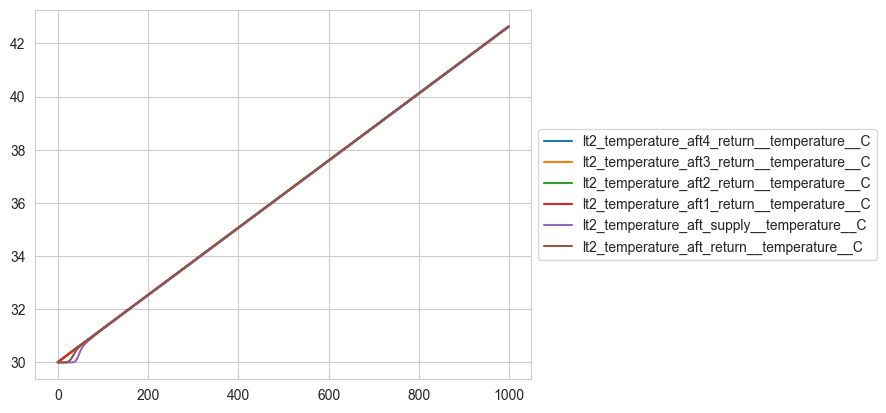

In [15]:
ax = result[[x for x in result.columns if ("lt2_temperature" in x) and 'aft' in x]].to_pandas().head(1000).plot()
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

In [6]:
result[[x for x in result.columns if "temperature" in x]][600]

lt2_temperature_aft4_return__temperature__C,lt2_temperature_aft3_return__temperature__C,lt2_temperature_aft2_return__temperature__C,lt2_temperature_aft1_return__temperature__C,lt2_temperature_ugrid2_return__temperature__C,lt2_temperature_ugrid1_return__temperature__C,lt2_temperature_fwd2_return__temperature__C,lt2_temperature_fwd1_return__temperature__C,lt2_temperature_aft_supply__temperature__C,lt2_temperature_recovery_mix__temperature__C,lt2_temperature_supply__temperature__C,lt2_temperature_fwd_return__temperature__C,lt2_temperature_aft_return__temperature__C,lt2_temperature_recovery__temperature__C,lt2_temperature_recovery_return__temperature__C,lt2_temperature_fwd_supply__temperature__C,lt2_temperature_ugrid_supply__temperature__C,lt2_temperature_ugrid_return__temperature__C,lt2_flow_aft4__temperature__C,lt2_flow_aft3__temperature__C,lt2_flow_aft2__temperature__C,lt2_flow_aft1__temperature__C,lt2_flow_ugrid2__temperature__C,lt2_flow_ugrid1__temperature__C,lt2_flow_fwd2__temperature__C,lt2_flow_fwd1__temperature__C,lt2_flow_aft_return__temperature__C,lt2_flow_fwd_return__temperature__C,lt2_flow_recovery__temperature__C,lt2_flow_ugrid_return__temperature__C,lt2_seawater_return__temperature__C,lt2_boilers_return__temperature__C,lt2_seawater_supply__temperature__C,lt2_boilers_supply__temperature__C
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
37.593853,37.593853,37.593853,37.593853,59.920335,59.920335,37.49274,37.49274,37.57739,30.0,30.0,37.485261,37.590238,30.051159,30.0,37.45908,59.875427,59.910362,37.573673,37.573673,37.573673,37.573673,59.865454,59.865454,37.4516,37.4516,37.590238,37.485261,30.000078,59.910362,20.0,35.0,20.0,35.0


In [17]:
result[
    [
        x
        for x in result.columns
        if ("temperature_supply" in x) or ("temperature_recovery_mix" in x)
    ]
]

lt2_temperature_recovery_mix__temperature__C,lt2_temperature_supply__temperature__C
f64,f64
30.0,30.0
30.0,30.0
30.0,30.0
30.0,30.0
30.0,30.0
…,…
38.902982,37.79408
38.901739,37.791576
38.902994,37.794078


In [21]:
result[[x for x in result.columns if ("recovery" in x)]]

lt2_temperature_recovery_mix__temperature__C,lt2_temperature_recovery__temperature__C,lt2_temperature_recovery_return__temperature__C,lt2_mix_recovery__position_rel__ratio,lt2_flow_recovery__flow__l_min,lt2_flow_recovery__temperature__C,lt2_mix_recovery__setpoint__ratio
f64,f64,f64,f64,f64,f64,f64
30.0,30.0,30.0,0.00001,-0.0,30.0,0.0
30.0,30.0,30.0,0.011108,9.7379e-20,30.0,0.22
30.0,30.0,30.0,0.022219,-4.3217e-14,30.0,0.24
30.0,29.99994,30.000002,0.03333,0.000003,30.0,0.26
30.0,29.999894,30.000003,0.044442,0.000004,30.0,0.279999
…,…,…,…,…,…,…
38.902982,39.957889,38.90262,1.0,49.69368,39.958243,1.0
38.901739,39.969432,38.902067,1.0,49.416412,39.968893,1.0
38.902994,39.957899,38.902635,1.0,49.693911,39.958266,1.0


In [32]:
from thrs.simulation.io_mapping import flatten_model_values


result.select(
    [
        "time",
        *flatten_model_values(Lt2ControlValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(Lt2SimulationInputs.zero(), fmu_only=False).keys(),
    ]
).write_csv("csv/lt2_run_inputs_cooling13_4.csv")


result.select(
    [
        "time",
        *flatten_model_values(Lt2SensorValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(Lt2SimulationOutputs.zero(), fmu_only=False).keys(),
    ]
).write_csv("csv/lt2_run_outputs_cooling13_4.csv")